# Word2Vec from Scratch

In this notebook, we'll implement **Word2Vec** from scratch using PyTorch. Word2Vec revolutionized NLP by learning dense vector representations of words that capture semantic meaning.

## What We'll Build

- **Skip-gram model** with negative sampling
- Word embeddings trained on a text corpus
- Tools for finding similar words and solving word analogies

## What Intuitions We'll Develop

- How words can be represented as vectors in continuous space
- Why "you shall know a word by the company it keeps"
- How negative sampling makes training efficient
- Why vector arithmetic captures semantic relationships (e.g., king - man + woman ≈ queen)

## 1. Setup

Import necessary libraries and configure the environment.

In [ ]:


%load_ext autoreload
%autoreload 2

Set random seed for reproducibility.

In [ ]:
from aiml_notebooks import get_device, set_seed

In [2]:
set_seed(42)

Configure device for training.

In [3]:
device = get_device()
print(f"Using device: {device}")

Using MPS (Metal Performance Shaders) for GPU acceleration
Using device: mps


## 2. The Core Idea: Distributional Semantics

### The Distributional Hypothesis

**"You shall know a word by the company it keeps"** - J.R. Firth (1957)

This is the foundation of Word2Vec. Words that appear in similar contexts tend to have similar meanings.

For example:
- "The **cat** sat on the mat"
- "The **dog** sat on the mat"

Since "cat" and "dog" appear in similar contexts (with words like "sat", "mat"), they should have similar vector representations.

### Two Architectures: CBOW vs Skip-gram

Word2Vec has two variants:

1. **CBOW (Continuous Bag of Words)**: Predicts target word from context words
   - Input: context words → Output: target word
   - Example: ["the", "sat", "on"] → "cat"

2. **Skip-gram**: Predicts context words from target word (what we'll implement)
   - Input: target word → Output: context words
   - Example: "cat" → ["the", "sat", "on"]

Skip-gram works better with small datasets and rare words, so we'll focus on it.

## 3. Prepare Training Data

### Load and Preprocess Corpus

We'll use a simple text corpus for demonstration. In practice, Word2Vec is trained on millions or billions of words, but we'll use a smaller dataset to make training fast.

In [4]:
# Simple corpus for demonstration
corpus = """
the quick brown fox jumps over the lazy dog
the dog barks at the cat
the cat sleeps on the mat
the fox runs through the forest
the bird flies over the tree
the tree stands in the forest
the dog chases the cat
the cat climbs the tree
the fox hides in the forest
the bird sings in the tree
the dog plays in the park
the cat hunts the mouse
the mouse hides from the cat
the bird builds a nest
the fox catches the mouse
""".strip()

# Tokenize: split into words and lowercase
tokens = corpus.lower().split()
print(f"Total tokens: {len(tokens)}")
print(f"Sample tokens: {tokens[:20]}")

Total tokens: 88
Sample tokens: ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', 'the', 'dog', 'barks', 'at', 'the', 'cat', 'the', 'cat', 'sleeps', 'on', 'the']


### Build Vocabulary

Create mappings between words and indices. We'll also count word frequencies for negative sampling later.

In [ ]:
from collections import Counter

In [5]:
# Count word frequencies
word_counts = Counter(tokens)
vocab = sorted(word_counts.keys())
vocab_size = len(vocab)

# Create word <-> index mappings
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

print(f"Vocabulary size: {vocab_size}")
print(f"Most common words: {word_counts.most_common(10)}")

Vocabulary size: 35
Most common words: [('the', 29), ('cat', 6), ('fox', 4), ('dog', 4), ('tree', 4), ('in', 4), ('forest', 3), ('bird', 3), ('mouse', 3), ('over', 2)]


### Create Training Pairs

For Skip-gram, we create (target, context) pairs. The **context window** determines how many surrounding words we consider.

For example, with window size 2 and the sentence "the cat sat on the mat":
- Target: "cat" → Context: ["the", "sat", "on"]
- Target: "sat" → Context: ["the", "cat", "on", "the"]

We create one training pair for each (target, context_word) combination.

In [6]:
def create_skipgram_pairs(tokens, window_size=2):
    """Create (target, context) pairs for skip-gram training."""
    pairs = []
    
    for i, target_word in enumerate(tokens):
        # Get context words within window
        start = max(0, i - window_size)
        end = min(len(tokens), i + window_size + 1)
        
        for j in range(start, end):
            if i != j:  # Don't pair word with itself
                context_word = tokens[j]
                pairs.append((target_word, context_word))
    
    return pairs

# Create training pairs
window_size = 2
training_pairs = create_skipgram_pairs(tokens, window_size)

print(f"Total training pairs: {len(training_pairs)}")
print(f"Sample pairs: {training_pairs[:10]}")

Total training pairs: 346
Sample pairs: [('the', 'quick'), ('the', 'brown'), ('quick', 'the'), ('quick', 'brown'), ('quick', 'fox'), ('brown', 'the'), ('brown', 'quick'), ('brown', 'fox'), ('brown', 'jumps'), ('fox', 'quick')]


Let's visualize what the context window looks like for a specific word.

In [7]:
# Example: show context for word at position 5
example_idx = 5
example_sentence = tokens[:15]
target = example_sentence[example_idx]

start = max(0, example_idx - window_size)
end = min(len(example_sentence), example_idx + window_size + 1)
context = [example_sentence[i] for i in range(start, end) if i != example_idx]

print(f"Sentence: {' '.join(example_sentence)}")
print(f"Target word (index {example_idx}): '{target}'")
print(f"Context words (window={window_size}): {context}")

Sentence: the quick brown fox jumps over the lazy dog the dog barks at the cat
Target word (index 5): 'over'
Context words (window=2): ['fox', 'jumps', 'the', 'lazy']


## 4. Understanding Negative Sampling

### Why Negative Sampling?

Training Word2Vec naively would require computing softmax over the entire vocabulary for every training example - extremely expensive!

**Negative sampling** is a clever trick that makes training efficient:
- For each (target, context) pair, we sample a few "negative" words (words that don't appear in the context)
- Instead of predicting the probability of all words, we do binary classification: is this word in the context or not?

This reduces the problem from multi-class classification (vocab_size classes) to binary classification repeated k times.

### Sampling Distribution

We don't sample negative words uniformly. Instead, we use a **unigram distribution raised to the power of 3/4**:

$$P(w_i) = \frac{f(w_i)^{3/4}}{\sum_j f(w_j)^{3/4}}$$

Where $f(w_i)$ is the frequency of word $w_i$. This gives rare words a slightly higher chance of being sampled as negatives.

In [8]:
# Compute sampling probabilities
word_freqs = np.array([word_counts[idx2word[i]] for i in range(vocab_size)])
word_freqs = word_freqs ** 0.75  # Raise to power of 3/4
word_probs = word_freqs / word_freqs.sum()  # Normalize

print("Sampling probabilities (top 10):")
for i in range(10):
    print(f"{idx2word[i]:10s} - freq: {word_counts[idx2word[i]]:3d}, prob: {word_probs[i]:.4f}")

Sampling probabilities (top 10):
a          - freq:   1, prob: 0.0162
at         - freq:   1, prob: 0.0162
barks      - freq:   1, prob: 0.0162
bird       - freq:   3, prob: 0.0369
brown      - freq:   1, prob: 0.0162
builds     - freq:   1, prob: 0.0162
cat        - freq:   6, prob: 0.0620
catches    - freq:   1, prob: 0.0162
chases     - freq:   1, prob: 0.0162
climbs     - freq:   1, prob: 0.0162


Notice how common words like "the" still have high sampling probability, but less common words get a boost compared to their raw frequency.

## 5. Build the Dataset

Create a PyTorch Dataset that returns (target, context, negatives) for each training example.

In [ ]:
from torch.utils.data import Dataset, DataLoader

In [9]:
class SkipGramDataset(Dataset):
    """Dataset for Skip-gram with negative sampling."""
    
    def __init__(self, pairs, word2idx, word_probs, num_negatives=5):
        self.pairs = [(word2idx[target], word2idx[context]) 
                     for target, context in pairs]
        self.word_probs = word_probs
        self.num_negatives = num_negatives
        self.vocab_size = len(word_probs)
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        target_idx, context_idx = self.pairs[idx]
        
        # Sample negative examples
        neg_indices = []
        while len(neg_indices) < self.num_negatives:
            neg_idx = np.random.choice(self.vocab_size, p=self.word_probs)
            # Make sure negative is not the actual context word
            if neg_idx != context_idx:
                neg_indices.append(neg_idx)
        
        return (
            torch.tensor(target_idx, dtype=torch.long),
            torch.tensor(context_idx, dtype=torch.long),
            torch.tensor(neg_indices, dtype=torch.long)
        )

# Create dataset and dataloader
num_negatives = 5
dataset = SkipGramDataset(training_pairs, word2idx, word_probs, num_negatives)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

print(f"Dataset size: {len(dataset)}")
print(f"Number of batches: {len(dataloader)}")

Dataset size: 346
Number of batches: 3


Let's inspect a single batch to understand the data format.

In [10]:
# Get one batch
target, context, negatives = next(iter(dataloader))

print(f"Target shape: {target.shape}")
print(f"Context shape: {context.shape}")
print(f"Negatives shape: {negatives.shape}")
print()
print("First example:")
print(f"  Target: '{idx2word[target[0].item()]}'")
print(f"  Context (positive): '{idx2word[context[0].item()]}'")
print(f"  Negatives: {[idx2word[idx.item()] for idx in negatives[0]]}")

Target shape: torch.Size([128])
Context shape: torch.Size([128])
Negatives shape: torch.Size([128, 5])

First example:
  Target: 'over'
  Context (positive): 'jumps'
  Negatives: ['from', 'through', 'stands', 'over', 'cat']


## 6. The Skip-gram Model Architecture

### Model Structure

The Skip-gram model is surprisingly simple:

1. **Input embedding**: Map target word index to a dense vector (the word embedding)
2. **Output embedding**: Map context word indices to dense vectors
3. **Similarity**: Compute dot product between target and context embeddings
4. **Loss**: Maximize similarity for positive pairs, minimize for negative pairs

We maintain **two embedding matrices**:
- **Input embeddings** (what we'll use after training)
- **Output embeddings** (used during training, discarded after)

This separation helps the model learn better representations.

In [11]:
class SkipGramModel(nn.Module):
    """Skip-gram model with negative sampling."""
    
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        
        # Input embeddings (these are the word vectors we want to learn)
        self.input_embeddings = nn.Embedding(vocab_size, embedding_dim)
        
        # Output embeddings (used for predicting context)
        self.output_embeddings = nn.Embedding(vocab_size, embedding_dim)
        
        # Initialize with small random values
        self.input_embeddings.weight.data.uniform_(-0.5/embedding_dim, 0.5/embedding_dim)
        self.output_embeddings.weight.data.uniform_(-0.5/embedding_dim, 0.5/embedding_dim)
    
    def forward(self, target, context, negatives):
        """
        Args:
            target: (batch_size,) target word indices
            context: (batch_size,) positive context word indices
            negatives: (batch_size, num_negatives) negative word indices
        
        Returns:
            loss: scalar tensor
        """
        batch_size = target.shape[0]
        
        # Get embeddings
        # target_embed: (batch_size, embedding_dim)
        target_embed = self.input_embeddings(target)
        
        # context_embed: (batch_size, embedding_dim)
        context_embed = self.output_embeddings(context)
        
        # neg_embed: (batch_size, num_negatives, embedding_dim)
        neg_embed = self.output_embeddings(negatives)
        
        # Compute scores (dot products)
        # positive_score: (batch_size,)
        positive_score = (target_embed * context_embed).sum(dim=1)
        
        # negative_scores: (batch_size, num_negatives)
        negative_scores = torch.bmm(neg_embed, target_embed.unsqueeze(2)).squeeze(2)
        
        # Loss: maximize log sigmoid of positive scores, minimize log sigmoid of negative scores
        positive_loss = F.logsigmoid(positive_score).mean()
        negative_loss = F.logsigmoid(-negative_scores).sum(dim=1).mean()
        
        # Negative log likelihood
        return -(positive_loss + negative_loss)
    
    def get_embedding(self, word_idx):
        """Get the embedding for a word (used after training)."""
        return self.input_embeddings(torch.tensor([word_idx])).squeeze(0)

### Understanding the Loss Function

The loss consists of two parts:

1. **Positive loss**: $-\log(\sigma(\text{target} \cdot \text{context}))$ - we want this score to be high
2. **Negative loss**: $-\sum_i \log(\sigma(-\text{target} \cdot \text{negative}_i))$ - we want these scores to be low

Where $\sigma$ is the sigmoid function. This encourages the model to:
- Give high dot products for (target, context) pairs that actually occur together
- Give low dot products for (target, negative) pairs that don't occur together

Create the model and inspect its structure.

In [12]:
# Model hyperparameters
embedding_dim = 50

# Create model
model = SkipGramModel(vocab_size, embedding_dim).to(device)

# Count parameters
num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")
print(f"Input embeddings shape: {model.input_embeddings.weight.shape}")
print(f"Output embeddings shape: {model.output_embeddings.weight.shape}")

Model parameters: 3,500
Input embeddings shape: torch.Size([35, 50])
Output embeddings shape: torch.Size([35, 50])


## 7. Training Loop

Set up the optimizer and training configuration.

In [13]:
# Training hyperparameters
num_epochs = 100
learning_rate = 0.025

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(f"Training configuration:")
print(f"  Epochs: {num_epochs}")
print(f"  Learning rate: {learning_rate}")
print(f"  Embedding dimension: {embedding_dim}")
print(f"  Number of negatives: {num_negatives}")
print(f"  Window size: {window_size}")

Training configuration:
  Epochs: 100
  Learning rate: 0.025
  Embedding dimension: 50
  Number of negatives: 5
  Window size: 2


Train the model and track loss over time.

In [ ]:
from tqdm.auto import tqdm

In [14]:
# Training loop
losses = []
model.train()

for epoch in tqdm(range(num_epochs), desc="Training"):
    epoch_loss = 0
    
    for target, context, negatives in dataloader:
        # Move to device
        target = target.to(device)
        context = context.to(device)
        negatives = negatives.to(device)
        
        # Forward pass
        loss = model(target, context, negatives)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}: Loss = {avg_loss:.4f}")

print("\nTraining complete!")

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch  10: Loss = 2.4548
Epoch  20: Loss = 2.1208
Epoch  30: Loss = 2.0142
Epoch  40: Loss = 2.0455
Epoch  50: Loss = 1.9751
Epoch  60: Loss = 1.9874
Epoch  70: Loss = 1.9855
Epoch  80: Loss = 1.9731
Epoch  90: Loss = 1.9953
Epoch 100: Loss = 1.9557

Training complete!


Visualize the training loss curve.

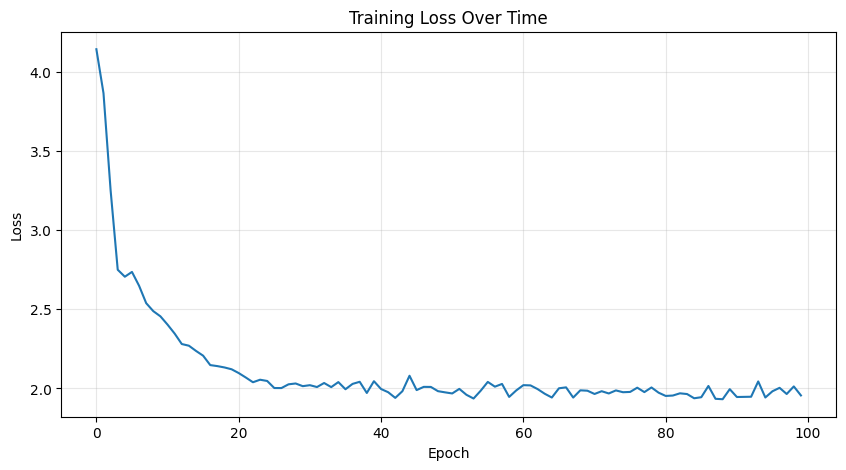

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.show()

The loss should decrease steadily, indicating the model is learning meaningful word representations.

## 8. Extract and Explore Word Embeddings

Now that training is complete, let's extract the learned embeddings and explore what they've captured.

In [16]:
# Extract embeddings as numpy array
model.eval()
embeddings = model.input_embeddings.weight.detach().cpu().numpy()

print(f"Embeddings shape: {embeddings.shape}")
print(f"Each of {vocab_size} words is represented by a {embedding_dim}-dimensional vector")

Embeddings shape: (35, 50)
Each of 35 words is represented by a 50-dimensional vector


### Cosine Similarity

To measure how similar two word vectors are, we use **cosine similarity**:

$$\text{similarity}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{||\mathbf{a}|| \cdot ||\mathbf{b}||}$$

This measures the angle between vectors, ranging from -1 (opposite) to 1 (identical).

In [17]:
def cosine_similarity(vec1, vec2):
    """Compute cosine similarity between two vectors."""
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

def most_similar(word, embeddings, word2idx, idx2word, top_k=5):
    """Find the most similar words to a given word."""
    if word not in word2idx:
        return f"Word '{word}' not in vocabulary"
    
    word_idx = word2idx[word]
    word_vec = embeddings[word_idx]
    
    # Compute similarities with all words
    similarities = []
    for idx in range(len(embeddings)):
        if idx != word_idx:  # Skip the word itself
            sim = cosine_similarity(word_vec, embeddings[idx])
            similarities.append((idx2word[idx], sim))
    
    # Sort by similarity and return top k
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_k]

### Find Similar Words

Let's test if the model has learned that semantically similar words have similar vectors.

In [18]:
# Test with a few words
test_words = ['cat', 'dog', 'tree', 'forest']

for word in test_words:
    similar = most_similar(word, embeddings, word2idx, idx2word, top_k=5)
    print(f"\nMost similar to '{word}':")
    for similar_word, similarity in similar:
        print(f"  {similar_word:10s} - similarity: {similarity:.3f}")


Most similar to 'cat':
  sleeps     - similarity: 0.677
  on         - similarity: 0.580
  barks      - similarity: 0.565
  mat        - similarity: 0.532
  hunts      - similarity: 0.520

Most similar to 'dog':
  barks      - similarity: 0.684
  plays      - similarity: 0.647
  stands     - similarity: 0.588
  at         - similarity: 0.499
  lazy       - similarity: 0.495

Most similar to 'tree':
  stands     - similarity: 0.728
  plays      - similarity: 0.662
  lazy       - similarity: 0.656
  jumps      - similarity: 0.575
  runs       - similarity: 0.518

Most similar to 'forest':
  sings      - similarity: 0.876
  plays      - similarity: 0.798
  flies      - similarity: 0.635
  stands     - similarity: 0.629
  runs       - similarity: 0.616


Notice how animals (cat, dog) are similar to each other, and nature words (tree, forest) cluster together. This demonstrates that the embeddings captured semantic relationships!

## 9. Visualize Embeddings with t-SNE

### Dimensionality Reduction

Our embeddings are 50-dimensional, which is hard to visualize. We'll use **t-SNE** to project them into 2D while preserving local similarity structure.

t-SNE (t-Distributed Stochastic Neighbor Embedding) finds a 2D representation where similar points stay close together.

In [19]:
from sklearn.manifold import TSNE

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, vocab_size-1))
embeddings_2d = tsne.fit_transform(embeddings)

print(f"Reduced embeddings shape: {embeddings_2d.shape}")

Reduced embeddings shape: (35, 2)


Plot all words in 2D space.

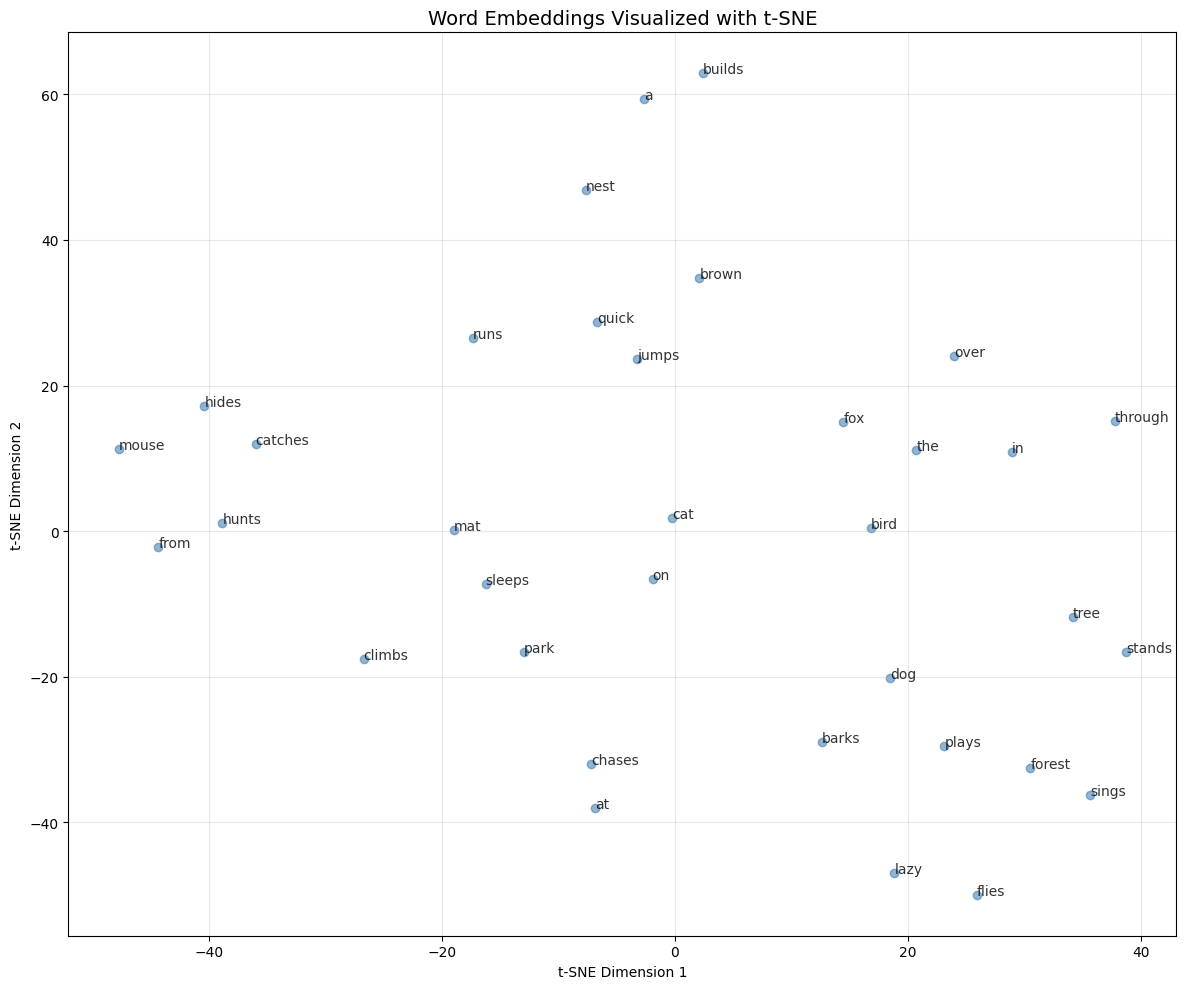

In [20]:
plt.figure(figsize=(12, 10))

# Plot each word
for idx in range(vocab_size):
    x, y = embeddings_2d[idx]
    plt.scatter(x, y, c='steelblue', alpha=0.6)
    plt.annotate(idx2word[idx], (x, y), fontsize=10, alpha=0.8)

plt.title('Word Embeddings Visualized with t-SNE', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In the visualization, you should see clusters of related words:
- Animals (cat, dog, bird, mouse, fox) tend to group together
- Nature words (tree, forest) form clusters
- Action words might cluster separately

This spatial organization reflects the semantic structure learned by the model!

## 10. Word Analogies

### Vector Arithmetic

One of the most famous properties of word embeddings is that **vector arithmetic captures semantic relationships**.

The classic example is:
$$\text{king} - \text{man} + \text{woman} \approx \text{queen}$$

This works because the vector difference captures the concept of "royalty" independent of gender.

We can solve analogies like "A is to B as C is to ?"
by computing: $\text{B} - \text{A} + \text{C}$ and finding the nearest word.

In [21]:
def analogy(word_a, word_b, word_c, embeddings, word2idx, idx2word, top_k=3):
    """
    Solve analogy: word_a is to word_b as word_c is to ?
    Returns top_k candidates for the answer.
    """
    # Check if all words are in vocabulary
    for word in [word_a, word_b, word_c]:
        if word not in word2idx:
            return f"Word '{word}' not in vocabulary"
    
    # Get vectors
    vec_a = embeddings[word2idx[word_a]]
    vec_b = embeddings[word2idx[word_b]]
    vec_c = embeddings[word2idx[word_c]]
    
    # Compute target vector: b - a + c
    target_vec = vec_b - vec_a + vec_c
    
    # Find most similar words to target
    similarities = []
    exclude = {word2idx[word_a], word2idx[word_b], word2idx[word_c]}
    
    for idx in range(len(embeddings)):
        if idx not in exclude:
            sim = cosine_similarity(target_vec, embeddings[idx])
            similarities.append((idx2word[idx], sim))
    
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_k]

Test some analogies with our trained embeddings. Note that with our small corpus, the results may not be as impressive as with large-scale Word2Vec models.

In [22]:
# Try some analogies
analogies = [
    ('dog', 'barks', 'cat'),   # dog:barks as cat:?
    ('cat', 'mouse', 'fox'),   # cat:mouse as fox:?
]

for word_a, word_b, word_c in analogies:
    print(f"\n'{word_a}' is to '{word_b}' as '{word_c}' is to:")
    results = analogy(word_a, word_b, word_c, embeddings, word2idx, idx2word)
    if isinstance(results, str):
        print(f"  {results}")
    else:
        for word, similarity in results:
            print(f"  {word:10s} - similarity: {similarity:.3f}")


'dog' is to 'barks' as 'cat' is to:
  chases     - similarity: 0.603
  sleeps     - similarity: 0.598
  hunts      - similarity: 0.522

'cat' is to 'mouse' as 'fox' is to:
  from       - similarity: 0.484
  brown      - similarity: 0.469
  catches    - similarity: 0.428


## 11. Exploring Semantic Clusters

Let's create a similarity matrix to see which words cluster together.

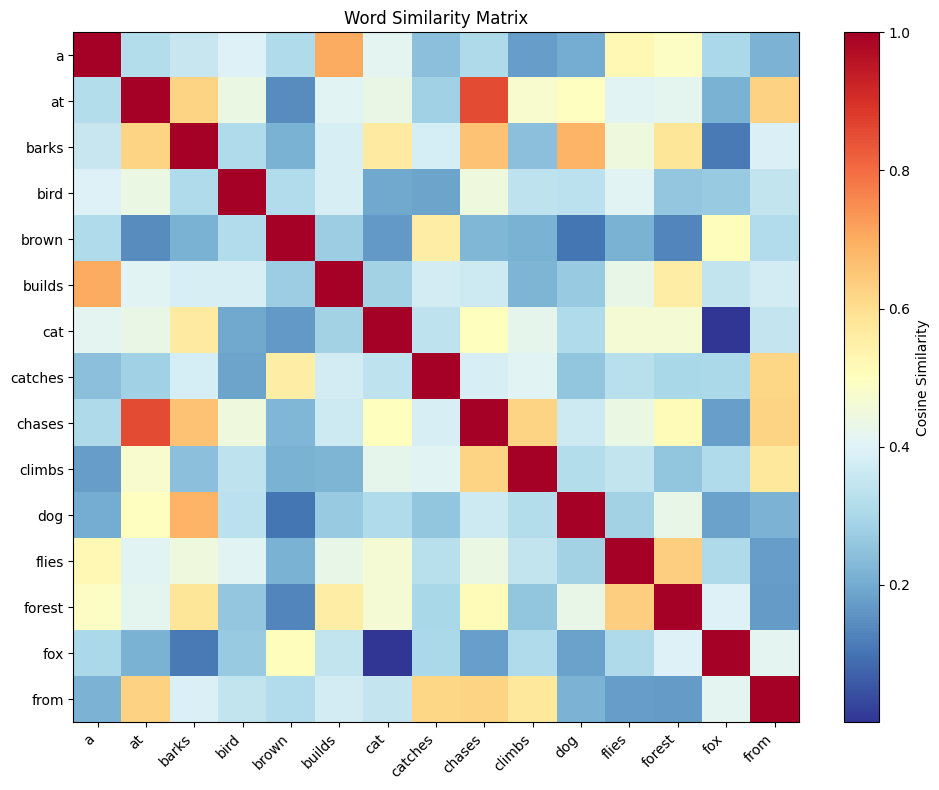

In [23]:
# Compute pairwise similarity matrix
similarity_matrix = np.zeros((vocab_size, vocab_size))
for i in range(vocab_size):
    for j in range(vocab_size):
        similarity_matrix[i, j] = cosine_similarity(embeddings[i], embeddings[j])

# Visualize as heatmap (select subset for clarity)
n_words = min(15, vocab_size)
selected_indices = list(range(n_words))
selected_words = [idx2word[i] for i in selected_indices]

plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix[:n_words, :n_words], cmap='RdYlBu_r', aspect='auto')
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(n_words), selected_words, rotation=45, ha='right')
plt.yticks(range(n_words), selected_words)
plt.title('Word Similarity Matrix')
plt.tight_layout()
plt.show()

Darker red indicates higher similarity. You should see blocks of high similarity where related words cluster together.

## 12. Key Takeaways

### What We Learned

1. **Distributional Semantics**: Words that appear in similar contexts have similar meanings, and this can be captured with vector representations

2. **Skip-gram Architecture**: Predicting context from target words is a simple but effective way to learn embeddings

3. **Negative Sampling**: Makes training efficient by converting the problem from multi-class to binary classification

4. **Vector Space Properties**:
   - Cosine similarity measures semantic similarity
   - Vector arithmetic captures semantic relationships
   - Similar words cluster together in embedding space

5. **Training Trade-offs**:
   - Larger embedding dimensions capture more nuance but are more expensive
   - More negative samples improve quality but slow training
   - Window size affects what "context" means

### Limitations of Our Implementation

- **Small corpus**: Real Word2Vec is trained on billions of tokens
- **No subsampling**: Frequent words are often subsampled to balance training
- **Simple tokenization**: Real systems use more sophisticated preprocessing

### Extensions to Try

- Train on a larger corpus (Wikipedia, news articles)
- Implement CBOW (the other Word2Vec variant)
- Add subsampling of frequent words
- Experiment with different embedding dimensions
- Compare to modern contextual embeddings (BERT, GPT)

### Why Word2Vec Matters

Word2Vec was a breakthrough that transformed NLP:

- Showed that simple models + lots of data can learn rich representations
- Made transfer learning practical in NLP (pre-train embeddings, use in downstream tasks)
- Inspired modern architectures like ELMo, BERT, and GPT

While contextual embeddings have largely superseded Word2Vec, the core ideas remain fundamental to modern NLP!